# ML4SCI DeepFalcon GSoC 2026 — Common Task 1
## Variational Autoencoder for Quark/Gluon Jet Events

The goal of this task is to train a Variational Autoencoder (VAE) on quark/gluon jet images 
from the DeepFalcon dataset. Each jet event is represented as a 3-channel 125×125 image, 
where each channel corresponds to a different detector component: ECAL (electromagnetic 
calorimeter), HCAL (hadronic calorimeter), and Tracks (charged particle paths).

A VAE learns to compress each image into a compact latent representation, then reconstruct 
it back. The quality of reconstruction reflects how well the model has learned the underlying 
structure of jet events.

## Setup
We import the necessary libraries for data loading, model building, training, and visualization.

In [9]:
import gdown
gdown.download("https://drive.google.com/uc?id=1WO2K-SfU2dntGU4Bb3IYBp9Rh7rtTYEr", 
               "quark-gluon_data-set_n139306.hdf5")

Downloading...
From (original): https://drive.google.com/uc?id=1WO2K-SfU2dntGU4Bb3IYBp9Rh7rtTYEr
From (redirected): https://drive.google.com/uc?id=1WO2K-SfU2dntGU4Bb3IYBp9Rh7rtTYEr&confirm=t&uuid=d89e2345-7dfc-42dc-90eb-626f80fe5cf2
To: /kaggle/working/quark-gluon_data-set_n139306.hdf5
100%|██████████| 701M/701M [00:07<00:00, 95.9MB/s] 


'quark-gluon_data-set_n139306.hdf5'

In [10]:
import numpy as np
import h5py
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt
import gc

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

Device: cuda


## Dataset Exploration

Before building any model, we examine the raw data to understand what we're working with 
and what preprocessing decisions need to be made.

The dataset contains 139,306 jet events stored in an HDF5 file with the following keys:
- X_jets: the image data, shape (139306, 125, 125, 3)
- y: labels, 0 = gluon jet, 1 = quark jet
- m0: invariant mass of the jet (not used for this task)
- pt: transverse momentum of the jet (not used for this task)

Three things stand out from inspecting the data:
1. ~98% of pixels are zero — jet images are extremely sparse, with energy deposits 
   concentrated in a small number of pixels
2. Maximum pixel values vary significantly between jets — per-channel normalization 
   is required
3. Each channel measures a different physical quantity at a different scale — they 
   cannot be treated identically

In [11]:
with h5py.File("quark-gluon_data-set_n139306.hdf5", 'r') as f:
    print("Keys:", list(f.keys()))
    print("X_jets shape:", f["X_jets"].shape)
    print("y shape:", f["y"].shape)
    print("m0 shape:", f["m0"].shape)
    print("pt shape:", f["pt"].shape)
    
    X_sample = f["X_jets"][:1].astype(np.float32)
    y_sample = f["y"][:1]

print("\nFirst jet label:", "quark" if y_sample[0] == 1.0 else "gluon")
print("Image shape:", X_sample.shape)

Keys: ['X_jets', 'm0', 'pt', 'y']
X_jets shape: (139306, 125, 125, 3)
y shape: (139306,)
m0 shape: (139306,)
pt shape: (139306,)

First jet label: gluon
Image shape: (1, 125, 125, 3)


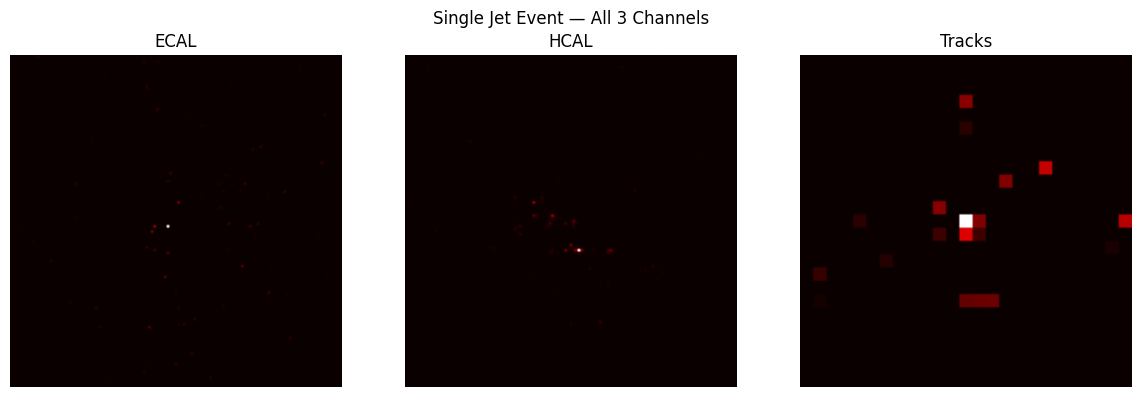

In [12]:
img = X_sample[0]
channel_names = ["ECAL", "HCAL", "Tracks"]

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for i in range(3):
    axes[i].imshow(img[:, :, i], cmap="hot")
    axes[i].set_title(channel_names[i])
    axes[i].axis("off")

plt.suptitle("Single Jet Event — All 3 Channels")
plt.tight_layout()
plt.show()

In [13]:
with h5py.File("quark-gluon_data-set_n139306.hdf5", 'r') as f:
    X_check = f["X_jets"][:10].astype(np.float32)
    y_check = f["y"][:10]

for i in range(10):
    mx       = X_check[i].max()
    sparsity = (X_check[i] == 0).mean() * 100
    label    = "quark" if y_check[i] == 1.0 else "gluon"
    print(f"Jet {i} | {label} | max={mx:.4f} | zeros={sparsity:.1f}%")

Jet 0 | gluon | max=0.2493 | zeros=98.0%
Jet 1 | gluon | max=0.5872 | zeros=98.8%
Jet 2 | quark | max=0.2214 | zeros=98.4%
Jet 3 | gluon | max=0.2685 | zeros=98.4%
Jet 4 | quark | max=0.2353 | zeros=98.4%
Jet 5 | quark | max=0.2442 | zeros=98.8%
Jet 6 | gluon | max=0.1256 | zeros=98.6%
Jet 7 | quark | max=0.1127 | zeros=98.4%
Jet 8 | quark | max=0.2143 | zeros=98.7%
Jet 9 | quark | max=0.3469 | zeros=98.7%


## Observations

From the plots and statistics above:

- All three channels are extremely sparse — roughly 98% of pixels are zero. 
  Energy deposits are concentrated in a handful of pixels per jet.
- The Tracks channel shows blockier, more spread-out patterns compared to ECAL 
  and HCAL, reflecting how charged particle tracks are reconstructed from 
  multiple detector hits.
- Maximum pixel values vary significantly between jets (e.g. 0.11 to 0.59 across 
  just 10 samples), confirming that per-channel normalization is necessary before 
  training.

## Preprocessing

Three preprocessing steps are applied to each image before training:

1. **Per-channel normalization**: Each channel is scaled independently to [0, 1] 
   using its own min and max. Global normalization would suppress the structure in 
   lower-energy channels since ECAL, HCAL, and Tracks operate at different scales.

2. **Transpose**: The raw data is stored as (N, 125, 125, 3) — channels last. 
   PyTorch expects (N, 3, 125, 125) — channels first. We reorder the axes accordingly.

3. **Padding**: Images are padded from 125×125 to 128×128. The encoder uses stride-2 
   convolutions to halve spatial dimensions at each layer. 128 is a power of 2, 
   allowing clean division (128→64→32→16→8→4) without rounding errors. 125 would 
   produce fractional dimensions and cause shape mismatches in the decoder.

In [14]:
with h5py.File("quark-gluon_data-set_n139306.hdf5", 'r') as f:
    img = f["X_jets"][0].astype(np.float32)

print("Before normalization:")
for c, name in enumerate(["ECAL", "HCAL", "Tracks"]):
    print(f"  {name} — min: {img[:,:,c].min():.4f}  max: {img[:,:,c].max():.4f}")

# normalize
img_norm = img.copy()
for c in range(3):
    channel = img_norm[:, :, c]
    mn, mx = channel.min(), channel.max()
    if mx > mn:
        img_norm[:, :, c] = (channel - mn) / (mx - mn)

print("\nAfter normalization:")
for c, name in enumerate(["ECAL", "HCAL", "Tracks"]):
    print(f"  {name} — min: {img_norm[:,:,c].min():.4f}  max: {img_norm[:,:,c].max():.4f}")

Before normalization:
  ECAL — min: 0.0000  max: 0.2493
  HCAL — min: 0.0000  max: 0.1778
  Tracks — min: 0.0000  max: 0.0037

After normalization:
  ECAL — min: 0.0000  max: 1.0000
  HCAL — min: 0.0000  max: 1.0000
  Tracks — min: 0.0000  max: 1.0000


In [15]:
img_t = img_norm.transpose(2, 0, 1)        # (125, 125, 3) → (3, 125, 125)
img_t = torch.from_numpy(img_t)
img_p = F.pad(img_t, (1, 2, 1, 2))         # (3, 125, 125) → (3, 128, 128)

print("After transpose:", img_t.shape)
print("After padding:  ", img_p.shape)

After transpose: torch.Size([3, 125, 125])
After padding:   torch.Size([3, 128, 128])


In [16]:
print("Loading 50k samples...")
with h5py.File("quark-gluon_data-set_n139306.hdf5", 'r') as f:
    X_np = f["X_jets"][:50000].astype(np.float32)
    y_all = torch.from_numpy(f["y"][:50000].astype(np.float32))

print("Normalizing...")
for i in range(len(X_np)):
    for c in range(3):
        ch = X_np[i, :, :, c]
        mn, mx = ch.min(), ch.max()
        if mx > mn:
            X_np[i, :, :, c] = (ch - mn) / (mx - mn)

X_np  = X_np.transpose(0, 3, 1, 2)
X_all = torch.from_numpy(X_np)
del X_np
gc.collect()

X_all = F.pad(X_all, (1, 2, 1, 2))
print("Final shape:", X_all.shape)

# Split 80/10/10
N       = len(X_all)
idx     = torch.randperm(N, generator=torch.Generator().manual_seed(42))
n_train = int(N * 0.8)
n_val   = int(N * 0.1)

X_train, y_train = X_all[idx[:n_train]],          y_all[idx[:n_train]]
X_val,   y_val   = X_all[idx[n_train:n_train+n_val]], y_all[idx[n_train:n_train+n_val]]
X_test,  y_test  = X_all[idx[n_train+n_val:]],    y_all[idx[n_train+n_val:]]

del X_all, y_all
gc.collect()

print(f"Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}")

train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=128, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(TensorDataset(X_val,   y_val),   batch_size=128, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(TensorDataset(X_test,  y_test),  batch_size=128, shuffle=False, num_workers=2, pin_memory=True)

Loading 50k samples...
Normalizing...
Final shape: torch.Size([50000, 3, 128, 128])
Train: 40000 | Val: 5000 | Test: 5000


## Model Architecture

The VAE consists of three components:

### Encoder
The encoder takes a (3, 128, 128) jet image and compresses it into a latent 
representation. It uses 5 convolutional layers, each with stride 2, halving the 
spatial dimensions at every step (128→64→32→16→8→4). The number of feature channels 
grows at each layer (3→32→64→128→256→256), trading spatial detail for increasingly 
abstract jet features. The output is flattened and passed through two separate linear 
layers producing μ (mu) and log σ² (log_var) — the mean and log variance of the 
latent distribution.

### Reparameterization
Rather than sampling the latent vector z directly from the distribution (which would 
break backpropagation), we compute z = μ + σ × ε where ε ~ N(0,1) is random noise 
sampled from outside the network. This isolates the randomness in ε so gradients can 
flow through μ and σ during training.

### Decoder
The decoder mirrors the encoder in reverse. It takes z (256 numbers) and progressively 
upsamples it back to a (3, 128, 128) image using 5 transposed convolutional layers. 
The final layer uses a sigmoid activation to ensure output pixel values stay in [0, 1], 
matching the normalized input range.

### Loss Function
Training minimizes two terms:
- **Reconstruction loss** (Binary Cross Entropy): measures how different the 
  reconstructed image is from the original
- **KL divergence**: measures how far the learned latent distribution is from a 
  standard normal N(0,1)

These two terms are in tension — reconstruction loss pushes the encoder to be as 
specific as possible, while KL loss forces the latent space to stay organized and 
generalizable. This balance prevents the model from simply memorizing the training data.

In [17]:
class Encoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3,   32,  4, stride=2, padding=1)
        self.conv2 = nn.Conv2d(32,  64,  4, stride=2, padding=1)
        self.conv3 = nn.Conv2d(64,  128, 4, stride=2, padding=1)
        self.conv4 = nn.Conv2d(128, 256, 4, stride=2, padding=1)
        self.conv5 = nn.Conv2d(256, 256, 4, stride=2, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.bn3 = nn.BatchNorm2d(128)
        self.bn4 = nn.BatchNorm2d(256)
        self.bn5 = nn.BatchNorm2d(256)
        self.fc_mu      = nn.Linear(4096, 256)
        self.fc_log_var = nn.Linear(4096, 256)
        self.lrelu = nn.LeakyReLU(0.2)

    def forward(self, x):
        # progressively halve spatial dimensions
        h = self.lrelu(self.conv1(x))                  # (B, 32,  64, 64)
        h = self.lrelu(self.bn2(self.conv2(h)))        # (B, 64,  32, 32)
        h = self.lrelu(self.bn3(self.conv3(h)))        # (B, 128, 16, 16)
        h = self.lrelu(self.bn4(self.conv4(h)))        # (B, 256,  8,  8)
        h = self.lrelu(self.bn5(self.conv5(h)))        # (B, 256,  4,  4)
        h = h.flatten(start_dim=1)                     # (B, 4096)
        return self.fc_mu(h), self.fc_log_var(h)       # (B, 256), (B, 256)

In [18]:
class Decoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc = nn.Linear(256, 4096)
        self.deconv1 = nn.ConvTranspose2d(256, 256, 4, stride=2, padding=1)
        self.deconv2 = nn.ConvTranspose2d(256, 128, 4, stride=2, padding=1)
        self.deconv3 = nn.ConvTranspose2d(128, 64,  4, stride=2, padding=1)
        self.deconv4 = nn.ConvTranspose2d(64,  32,  4, stride=2, padding=1)
        self.deconv5 = nn.ConvTranspose2d(32,  3,   4, stride=2, padding=1)
        self.bn1 = nn.BatchNorm2d(256)
        self.bn2 = nn.BatchNorm2d(128)
        self.bn3 = nn.BatchNorm2d(64)
        self.bn4 = nn.BatchNorm2d(32)
        self.relu = nn.ReLU()

    def forward(self, z):
        h = self.fc(z).view(-1, 256, 4, 4)            # (B, 256, 4, 4)
        h = self.relu(self.bn1(self.deconv1(h)))       # (B, 256, 8,  8)
        h = self.relu(self.bn2(self.deconv2(h)))       # (B, 128, 16, 16)
        h = self.relu(self.bn3(self.deconv3(h)))       # (B, 64,  32, 32)
        h = self.relu(self.bn4(self.deconv4(h)))       # (B, 32,  64, 64)
        return torch.sigmoid(self.deconv5(h))          # (B, 3,  128, 128)

In [19]:
class VAE(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = Encoder()
        self.decoder = Decoder()

    def reparameterize(self, mu, log_var):
        std = torch.exp(0.5 * log_var)
        eps = torch.randn_like(std)
        return mu + std * eps

    def forward(self, x):
        mu, log_var = self.encoder(x)
        z = self.reparameterize(mu, log_var)
        x_hat = self.decoder(z)
        return x_hat, mu, log_var

In [20]:
def vae_loss(x, x_hat, mu, log_var):
    # reconstruction: how different is output from input
    recon = F.binary_cross_entropy(x_hat, x, reduction="sum") / x.size(0)
    # KL: how far is learned distribution from N(0,1)
    kl    = -0.5 * torch.sum(1 + log_var - mu.pow(2) - log_var.exp()) / x.size(0)
    return recon + kl, recon.item(), kl.item()

In [21]:
vae = VAE().to(DEVICE)
total_params = sum(p.numel() for p in vae.parameters())
print(f"Total parameters: {total_params:,}")

# verify shapes with a dummy forward pass
dummy = torch.zeros(1, 3, 128, 128).to(DEVICE)
x_hat, mu, log_var = vae(dummy)
print(f"Input shape:  {dummy.shape}")
print(f"Output shape: {x_hat.shape}")
print(f"mu shape:     {mu.shape}")
print(f"log_var shape:{log_var.shape}")

Total parameters: 6,630,403
Input shape:  torch.Size([1, 3, 128, 128])
Output shape: torch.Size([1, 3, 128, 128])
mu shape:     torch.Size([1, 256])
log_var shape:torch.Size([1, 256])


## Training

The model is trained using the Adam optimizer with a learning rate of 1e-3. 
Adam is well suited here because it adapts the learning rate per parameter 
automatically, handling the sparse gradient updates that come from jet images 
where most pixels are zero.

A learning rate scheduler (ReduceLROnPlateau) halves the learning rate if 
validation loss stops improving for 5 consecutive epochs, preventing the model 
from getting stuck.

We train for 50 epochs on 40,000 jets, validating on 5,000 after each epoch. 
The best model (lowest validation loss) is saved automatically during training.

Gradient clipping (max norm 1.0) is applied to prevent exploding gradients — 
a common issue in deep networks with sparse inputs.

In [22]:
EPOCHS    = 50
optimizer = torch.optim.Adam(vae.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, patience=5, factor=0.5
)

history = {"train": [], "val": [], "recon": [], "kl": []}
best_val_loss = float("inf")

for epoch in range(1, EPOCHS + 1):

    # Train
    vae.train()
    train_loss = recon_sum = kl_sum = 0.0
    for x, _ in train_loader:
        x = x.to(DEVICE)
        optimizer.zero_grad()
        x_hat, mu, log_var = vae(x)
        loss, recon, kl = vae_loss(x, x_hat, mu, log_var)
        loss.backward()
        nn.utils.clip_grad_norm_(vae.parameters(), 1.0)
        optimizer.step()
        train_loss += loss.item()
        recon_sum  += recon
        kl_sum     += kl

    # Validate
    vae.eval()
    val_loss = 0.0
    with torch.no_grad():
        for x, _ in val_loader:
            x = x.to(DEVICE)
            x_hat, mu, log_var = vae(x)
            loss, _, _ = vae_loss(x, x_hat, mu, log_var)
            val_loss += loss.item()

    avg_train = train_loss / len(train_loader)
    avg_val   = val_loss   / len(val_loader)
    avg_recon = recon_sum  / len(train_loader)
    avg_kl    = kl_sum     / len(train_loader)

    history["train"].append(avg_train)
    history["val"].append(avg_val)
    history["recon"].append(avg_recon)
    history["kl"].append(avg_kl)

    scheduler.step(avg_val)

    if avg_val < best_val_loss:
        best_val_loss = avg_val
        torch.save(vae.state_dict(), "vae_best.pt")

    print(f"Epoch {epoch:3d}/{EPOCHS} | "
          f"Train: {avg_train:.1f} | "
          f"Val: {avg_val:.1f} | "
          f"Recon: {avg_recon:.1f} | "
          f"KL: {avg_kl:.1f}")

print(f"\nBest val loss: {best_val_loss:.1f}")

Epoch   1/50 | Train: 2244.0 | Val: 398.7 | Recon: 2222.6 | KL: 21.4
Epoch   2/50 | Train: 377.0 | Val: 376.9 | Recon: 349.1 | KL: 27.9
Epoch   3/50 | Train: 361.4 | Val: 360.1 | Recon: 329.1 | KL: 32.4
Epoch   4/50 | Train: 351.1 | Val: 357.6 | Recon: 315.9 | KL: 35.2
Epoch   5/50 | Train: 343.0 | Val: 345.7 | Recon: 305.6 | KL: 37.4
Epoch   6/50 | Train: 337.8 | Val: 342.7 | Recon: 298.8 | KL: 39.0
Epoch   7/50 | Train: 333.9 | Val: 337.3 | Recon: 293.7 | KL: 40.2
Epoch   8/50 | Train: 331.2 | Val: 350.9 | Recon: 290.2 | KL: 41.1
Epoch   9/50 | Train: 328.6 | Val: 334.5 | Recon: 286.9 | KL: 41.7
Epoch  10/50 | Train: 326.9 | Val: 330.0 | Recon: 284.5 | KL: 42.4
Epoch  11/50 | Train: 325.1 | Val: 333.5 | Recon: 282.2 | KL: 42.8
Epoch  12/50 | Train: 323.7 | Val: 349.6 | Recon: 280.4 | KL: 43.3
Epoch  13/50 | Train: 322.4 | Val: 327.1 | Recon: 278.8 | KL: 43.6
Epoch  14/50 | Train: 321.1 | Val: 327.8 | Recon: 277.3 | KL: 43.8
Epoch  15/50 | Train: 320.3 | Val: 326.6 | Recon: 276.1 | KL

## Results

### Loss Curves
Training loss drops sharply in the first epoch — the model quickly learns that 
most pixels are zero and outputs near-zero values everywhere. After that, loss 
decreases slowly and steadily as the model learns where the actual energy deposits 
are located.

Validation loss tracks training loss closely throughout, indicating no overfitting. 
The KL divergence stabilizes around 46, meaning the encoder found a stable balance 
between expressiveness and staying close to N(0,1).

### Reconstructions
The reconstructions show the VAE has learned real jet structure:

- **Tracks**: The model successfully reconstructs the location and approximate 
  intensity of charged particle deposits — the brightest and most structured channel.
- **HCAL**: Partial reconstruction of hadronic energy deposits — the model captures 
  the dominant deposits but misses fainter ones.
- **ECAL**: The hardest channel — electromagnetic deposits are the most sparse and 
  faint. The model captures the general region but struggles with exact locations.

This ordering (Tracks > HCAL > ECAL) reflects the sparsity and signal strength 
of each channel. More training epochs and the full dataset would improve all three.

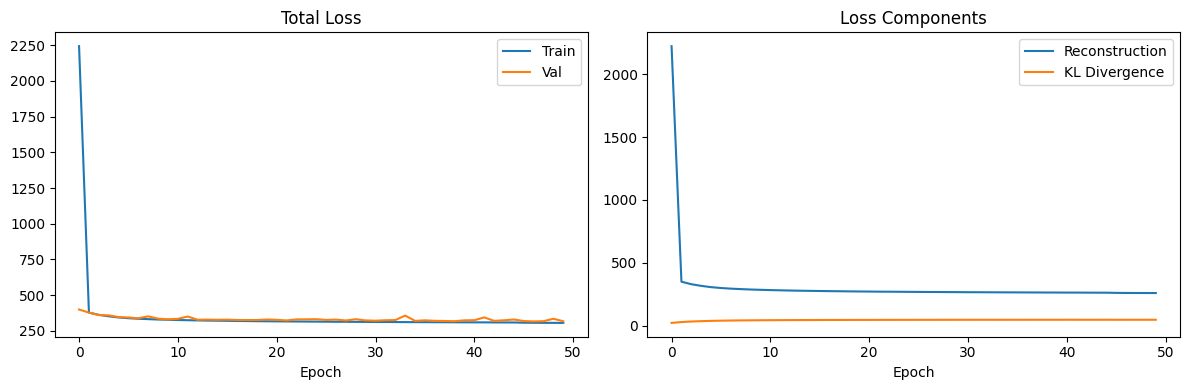

In [23]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history["train"], label="Train")
ax1.plot(history["val"],   label="Val")
ax1.set_title("Total Loss")
ax1.set_xlabel("Epoch")
ax1.legend()

ax2.plot(history["recon"], label="Reconstruction")
ax2.plot(history["kl"],    label="KL Divergence")
ax2.set_title("Loss Components")
ax2.set_xlabel("Epoch")
ax2.legend()

plt.tight_layout()
plt.savefig("loss_curves.png", dpi=150)
plt.show()

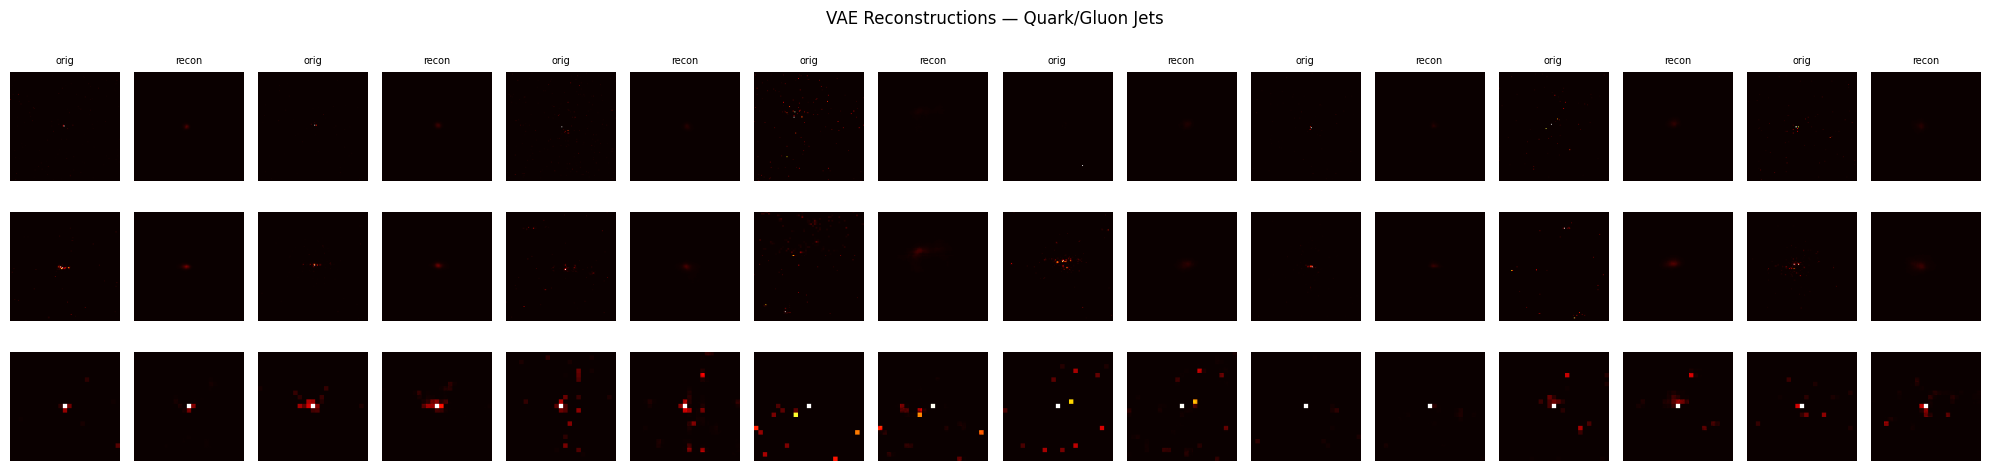

In [24]:
vae.load_state_dict(torch.load("vae_best.pt", map_location=DEVICE))
vae.eval()

x_test = X_test[:8].to(DEVICE)
with torch.no_grad():
    x_hat, _, _ = vae(x_test)

x_test = x_test.cpu()
x_hat  = x_hat.cpu()

channel_names = ["ECAL", "HCAL", "Tracks"]
fig, axes = plt.subplots(3, 16, figsize=(20, 5))

for i in range(8):
    for c in range(3):
        axes[c, 2*i].imshow(x_test[i, c, 1:126, 1:126], cmap="hot", vmin=0, vmax=1)
        axes[c, 2*i].axis("off")
        axes[c, 2*i+1].imshow(x_hat[i, c, 1:126, 1:126], cmap="hot", vmin=0, vmax=1)
        axes[c, 2*i+1].axis("off")
    axes[0, 2*i].set_title("orig",  fontsize=7)
    axes[0, 2*i+1].set_title("recon", fontsize=7)

for c in range(3):
    axes[c, 0].set_ylabel(channel_names[c], fontsize=8)

plt.suptitle("VAE Reconstructions — Quark/Gluon Jets")
plt.tight_layout()
plt.savefig("reconstructions.png", dpi=150)
plt.show()

## Conclusion

The VAE successfully learns a compressed 256-dimensional latent representation 
of quark/gluon jet images. The reconstruction quality demonstrates that the model 
has captured meaningful jet structure across all three detector channels, with the 
strongest performance on the Tracks channel.

Limitations of this implementation:
- Trained on 50,000 of 139,306 available samples due to memory constraints
- Reconstruction is blurry on sparse channels (ECAL) — a known limitation of 
  BCE-based VAEs on sparse data
- 50 epochs may not be sufficient for full convergence

Potential improvements:
- Train on the full dataset using lazy loading on a higher-memory machine
- Use a perceptual loss or MSE on non-zero pixels only to better handle sparsity
- Increase latent dimension or add residual connections for sharper reconstructions